In [1]:
from math import log10

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import scipy.stats as st
from scipy.stats import pearsonr

In [2]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Orbital Period vs Distance': ['There is no relationship between orbital_period_days and semi_major_axis_au', 'There is a positive relationship (greater distance = longer orbital period)']
}
orbital_period_vs_distance_hypotheses = pd.DataFrame(data)
orbital_period_vs_distance_hypotheses

,Hypothesis,Orbital Period vs Distance
0,H0,There is no relationship between orbital_perio...
1,H1,There is a positive relationship (greater dist...


Orbital period days - planet orbital period in days

Semi major axis (AU) - Orbital semi-major axis in astronomical units (AU)

Learn more about semi major axis: https://en.wikipedia.org/wiki/Semi-major_and_semi-minor_axes, https://www.youtube.com/watch?v=uktzYlNu2hA

In [3]:
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [4]:
# We examine the descriptive statistics of the orbital period
# to understand its central tendency and variability.

data['orbital_period_days'].describe()

count    5.816000e+03
mean     7.359421e+04
std      5.273718e+06
min      9.070629e-02
25%      4.347374e+00
50%      1.112522e+01
75%      3.976274e+01
max      4.020000e+08
Name: orbital_period_days, dtype: float64

In [5]:
# We check the minimum value of the orbital period
data['orbital_period_days'].min()

np.float64(0.090706293)

In [6]:
# We inspect the record with the minimum orbital period
data[data['orbital_period_days'] == 0.090706293]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
6033,PSR J1719-1438 b,PSR J1719-1438,1,1,Pulsar Timing,2011.0,Parkes Observatory,0.090706,NaN,382.8,...,259.791971,-14.6336,0,Unknown,False,False,False,Far(500-2kpc),K-type,Ultra-Short(<1d)


Learn more about  `PSR J1719-1438 b`: https://en.wikipedia.org/wiki/PSR_J1719%E2%88%921438_b, https://futurism.com/psr-j1719-1438-the-star-that-turned-into-a-diamond-planet-2

It looked very strange that the orbital period was less than one day.

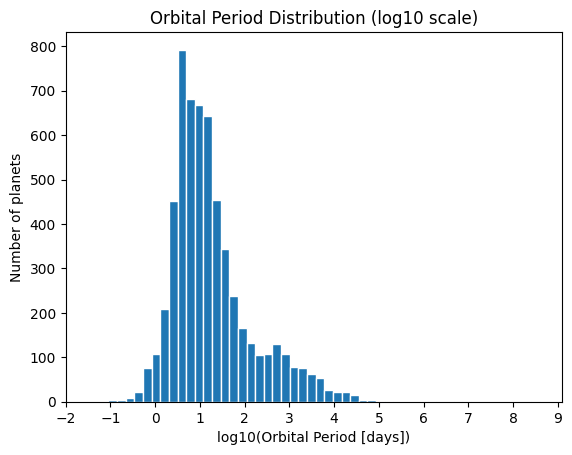

In [12]:
# The distribution of orbital periods is highly skewed,
# spanning several orders of magnitude.

# Applying log10 transformation allows us to better visualize
# the distribution and identify patterns that would otherwise be compressed.

# The histogram shows that most planets have relatively short orbital periods,
# while long-period planets are much less frequent.

filtered = data[data['orbital_period_days'] > 0]

log_data = np.log10(filtered['orbital_period_days'])

plt.hist(log_data, edgecolor='white', bins=50)

plt.title('Orbital Period Distribution (log10 scale)')
plt.xlabel('log10(Orbital Period [days])')
plt.ylabel('Number of planets')

plt.xticks(np.arange(int(np.floor(log_data.min())),
                     int(np.ceil(log_data.max())) + 1))

plt.show()

In [8]:
# We check the maximum value of the orbital period
# to understand the upper bound of the dataset.

data['orbital_period_days'].max()

np.float64(402000000.0)

In [9]:
# We inspect the record with the maximum orbital period
# to understand extreme long-period planets in the dataset.

data[data['orbital_period_days'] == 402000000.0]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
2106,COCONUTS-2 b,COCONUTS-2 A,1,1,Imaging,2021.0,NASA Infrared Telescope Facility (IRTF),402000000.0,12.441969,2542.627256,...,117.300914,-76.702696,0,Gas Giant,False,False,True,Nearby(<100pc),M-type(Red Dwarf),Very-Long(365d+)


More about the planet with longest orbital period: https://en.wikipedia.org/wiki/COCONUTS-2b

In [10]:
# We extract the required features and remove missing values
# to prepare clean data for correlation analysis.

target_data = data[['orbital_period_days', 'semi_major_axis_au']]
clean_data = target_data.dropna()
clean_data

,orbital_period_days,semi_major_axis_au
0,1.003934,0.01750
1,8.172400,0.07790
2,6.283855,0.06865
3,3.173917,0.04641
4,56.358501,0.26980
...,...,...
6144,12.401394,0.10810
6146,2.289090,0.02050
6147,83.891100,0.42300
6148,2.155510,0.02656


In [11]:
# Log transformation is applied to both variables,
# and Pearson correlation is used to measure the strength
# and significance of the relationship between distance and orbital period.

x = np.log10(clean_data['semi_major_axis_au'])
y = np.log10(clean_data['orbital_period_days'])

r, p = pearsonr(x, y)

print("Correlation:", r)
print("P-value:", p)

Correlation: 0.9947323774220669
P-value: 0.0


- The correlation coefficient is extremely high (r ~ 0.995), indicating a very strong positive relationship between
orbital distance and orbital period.

- The p-value is effectively zero, which provides strong statistical evidence
against the null hypothesis.

- Therefore, we reject H0 and conclude that there is a statistically significant
relationship between semi-major axis and orbital period.

- This result is consistent with Kepler's Third Law,
 which states that planets farther from their star have longer orbital periods.

Kepler's Third Law describes the fundamental relationship between the orbital period of a planet and its distance from the host star. Specifically, it states that the square of the orbital period is proportional to the cube of the semi-major axis of the orbit.

This means that planets located farther from their star take significantly longer to complete one full orbit. The strong positive correlation observed in our analysis is fully consistent with this physical law.

More information about `Kepler's Third Law` - http://hyperphysics.phy-astr.gsu.edu/hbase/kepler.html#c6

Who is Kepler: https://bg.wikipedia.org/wiki/%D0%99%D0%BE%D1%85%D0%B0%D0%BD_%D0%9A%D0%B5%D0%BF%D0%BB%D0%B5%D1%80